In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dataset import PatchDataset

DATA_DIR = ROOT / "data" / "images"
PATCH_SIZE = 64
SEED = 0

DATA_DIR

WindowsPath('d:/code/microlad/data')

In [6]:
dataset = PatchDataset(DATA_DIR, patch_size=PATCH_SIZE, seed=SEED)
sample = dataset[0]
len(dataset), sample.shape

(2, torch.Size([1, 64, 64]))

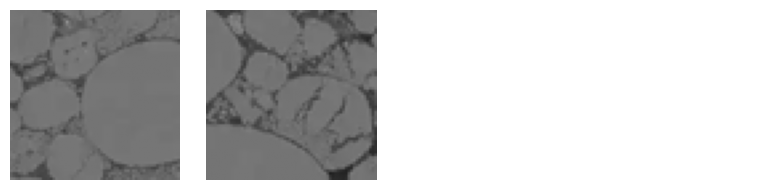

In [7]:
n = min(8, len(dataset))
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2), squeeze=False)

for ax in axes.ravel():
    ax.axis("off")

for index in range(n):
    sample = dataset[index]
    ax = axes[index // cols][index % cols]
    ax.imshow(sample.squeeze(0), cmap="gray", vmin=0, vmax=1)

plt.tight_layout()

In [8]:
loader = DataLoader(dataset, batch_size=8, shuffle=True)
batch = next(iter(loader))
batch.shape

torch.Size([2, 1, 64, 64])